In [1]:
import gymnasium as gym
import highway_env  # registers highway-v0, etc.
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from stable_baselines3 import SAC, TD3
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from stable_baselines3.common.callbacks import (
    EvalCallback, CheckpointCallback, BaseCallback
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise

SEED   = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
np.random.seed(SEED)

/Users/antoineoriou/Desktop/Travail/CS/3A/RL/Projet/RL_Highway/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Device: cpu


In [2]:
from config import ENV_CONFIG, SAC_KWARGS
from helper import make_env, EpisodeMetricsCallback

NAME = '500k-1653-ls'

TOTAL_TIMESTEPS = 500_000  
N_ENVS          = 4        
LOG_DIR         = Path("logs")
CKPT_DIR        = Path(f"checkpoints/{NAME}")
LOG_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)


**TRAINING SAC***

In [3]:
from config import ENV_CONFIG

sac_train_env = make_env(rank=0)
sac_eval_env  = make_env(rank=1, seed=100)

sac_metrics_cb = EpisodeMetricsCallback(log_path=f"metrics/sac_metrics{NAME}.csv")
sac_eval_cb    = EvalCallback(
    sac_eval_env,
    best_model_save_path = str(CKPT_DIR / "sac_best"),
    log_path             = str(LOG_DIR / "sac_eval"),
    eval_freq            = 10_000,
    n_eval_episodes      = 10,
    deterministic        = True,
    render               = False,
)
sac_ckpt_cb = CheckpointCallback(
    save_freq  = 50_000,
    save_path  = str(CKPT_DIR / "sac"),
    name_prefix= "sac_ckpt",
)

# Model 
sac_model = SAC(env=sac_train_env, **SAC_KWARGS)
print(sac_model.policy)

# Train 
sac_model.learn(
    total_timesteps = TOTAL_TIMESTEPS,
    callback        = [sac_metrics_cb, sac_eval_cb, sac_ckpt_cb],
    tb_log_name     = "SAC",
    reset_num_timesteps = True,
    progress_bar    = True,
)

sac_model.save(str(CKPT_DIR / "sac_final"))
sac_train_env.close()
sac_eval_env.close()

Using cpu device
Wrapping the env in a DummyVecEnv.
SACPolicy(
  (actor): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (latent_pi): Sequential(
      (0): Linear(in_features=50, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
    )
    (mu): Linear(in_features=256, out_features=2, bias=True)
    (log_std): Linear(in_features=256, out_features=2, bias=True)
  )
  (critic): ContinuousCritic(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (qf0): Sequential(
      (0): Linear(in_features=52, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): ReLU()
      (4): Linear(in_features=256, out_features=1, bias=True)
    )
    (qf1): Sequential(
      (0): Linear(in_features=52, out_features=256, bias=True)
      (1): ReLU()
  

/Users/antoineoriou/Desktop/Travail/CS/3A/RL/Projet/RL_Highway/.venv/lib/python3.13/site-packages/rich/live.py:260:
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7        |
|    ep_rew_mean     | 4.04     |
| time/              |          |
|    episodes        | 4        |
|    fps             | 157      |
|    time_elapsed    | 0        |
|    total_timesteps | 28       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 6.38     |
|    ep_rew_mean     | 3.64     |
| time/              |          |
|    episodes        | 8        |
|    fps             | 164      |
|    time_elapsed    | 0        |
|    total_timesteps | 51       |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 7.08     |
|    ep_rew_mean     | 4.11     |
| time/              |          |
|    episodes        | 12       |
|    fps             | 168      |
|    time_elapsed    | 0        |
|    total_timesteps | 85       |
--------------

Eval num_timesteps=10000, episode_reward=128.26 +/- 56.55

Episode length: 190.50 +/- 83.81

...

---------------------------------
| eval/              |          |
|    mean_ep_length  | 354      |
|    mean_reward     | 240      |
| time/              |          |
|    total_timesteps | 490000   |
| train/             |          |
|    actor_loss      | -41.1    |
|    critic_loss     | 10.3     |
|    ent_coef        | 0.0211   |
|    ent_coef_loss   | 1.39     |
|    learning_rate   | 0.001    |
|    n_updates       | 484999   |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 312      |
|    ep_rew_mean     | 213      |
| time/              |          |
|    episodes        | 2572     |
|    fps             | 93       |
|    time_elapsed    | 5232     |
|    total_timesteps | 490762   |
| train/             |          |
|    actor_loss      | -42.5    |
|    critic_loss     | 1.18     |
|    ent_coef        | 0.0203   |
|    ent_coef_loss   | 1.45     |
|    learning_rate   | 0.001    |
|    n_updates

Eval num_timesteps=500000, episode_reward=245.21 +/- 79.72

Episode length: 360.90 +/- 117.59

---------------------------------
| eval/              |          |
|    mean_ep_length  | 361      |
|    mean_reward     | 245      |
| time/              |          |
|    total_timesteps | 500000   |
| train/             |          |
|    actor_loss      | -41.8    |
|    critic_loss     | 1.38     |
|    ent_coef        | 0.0234   |
|    ent_coef_loss   | -0.803   |
|    learning_rate   | 0.001    |
|    n_updates       | 494999   |
---------------------------------


Metrics saved → metrics/sac_metrics500k-1653-ls.csv

**PLOTS**

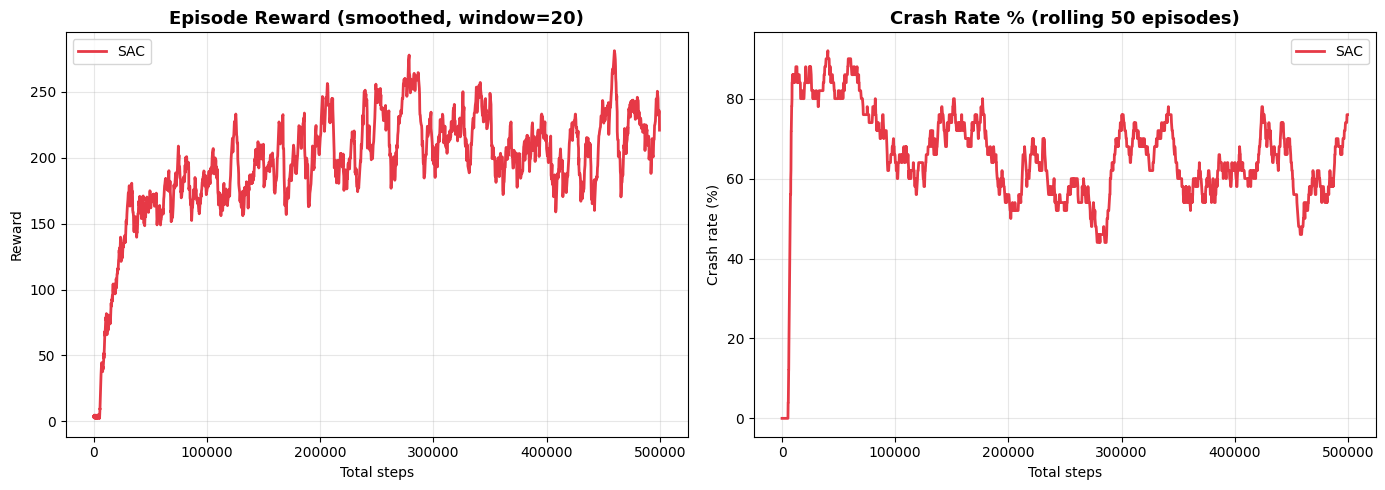

In [6]:
def smooth(y, window=20):
    """Simple running mean."""
    return pd.Series(y).rolling(window, min_periods=1).mean().values

sac_df = pd.read_csv(f"metrics/sac_metrics{NAME}.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Episode reward
ax = axes[0]
ax.plot(sac_df["total_steps"], smooth(sac_df["episode_reward"]),
        label="SAC", color="#E63946", linewidth=2)

ax.set_title("Episode Reward (smoothed, window=20)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total steps")
ax.set_ylabel("Reward")
ax.legend()
ax.grid(alpha=0.3)

# Crash rate (rolling 50-episode window)
ax = axes[1]
ax.plot(sac_df["total_steps"],
        pd.Series(sac_df["crashed"]).rolling(50, min_periods=1).mean() * 100,
        label="SAC", color="#E63946", linewidth=2)
ax.set_title("Crash Rate % (rolling 50 episodes)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total steps")
ax.set_ylabel("Crash rate (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_continuous.png", dpi=150)
plt.show()

**MULTI SEED EVAL**

In [ ]:
from helper import evaluate_model

EVAL_SEEDS = [100, 200, 300]
N_EVAL_EPS = 50

# Load best checkpoints
model = SAC.load(str(CKPT_DIR / "sac_best" / "best_model"))

results = []


seed_means = []
for s in EVAL_SEEDS:
    rews, crash_rate = evaluate_model(model, ENV_CONFIG, N_EVAL_EPS, seed=s)
    seed_means.append(rews.mean())
    results.append({"Model": "SAC", "Seed": s,
                    "Mean Reward": f"{rews.mean():.1f}±{rews.std():.1f}",
                    "Crash Rate %": f"{crash_rate:.0f}"})
overall = np.mean(seed_means)
results.append({"Model": "SAC", "Seed": "Overall",
                "Mean Reward": f"{overall:.2f}",
                "Crash Rate %": "—"})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))